In [1]:
from telescope import *
from spectrograph import *
from detector import *
from spectralmodels import get_sky_spectrum, get_list_of_stellar_models, get_stellar_spectrum
from etc.etc import SpecETC

from matplotlib import pyplot as plt

LRIS-B-600: Reading spectrograph efficiency from /Users/joshw/git/SpecETC/data/LRIS-Blue/600_mirr_eff.dat
IMX183: Reading detector efficiency from /Users/joshw/git/SpecETC/data/SonyIMX/QE.csv
IMX533: Reading detector efficiency from /Users/joshw/git/SpecETC/data/SonyIMX/QE.csv


In [2]:
IMX183.RN

1.2

In [3]:
models = get_list_of_stellar_models(verbose=True)
sptype = 'F8V'
mag = 11
star = get_stellar_spectrum(sptype=sptype, mag=mag)

O ['O5V', 'O9V', 'O8III']
B ['B1V', 'B2IV', 'B6IV', 'B9III', 'B8V', 'B2II', 'B3V', 'B5III', 'B1-2III', 'B5II', 'B0I', 'B0V', 'B8I', 'B5I', 'B5-7V']
A ['A0V', 'A2V', 'A4-7IV', 'A5III', 'A5V', 'A3V', 'A0IV', 'A0III', 'A0I']
F ['F8IV', 'F5III', 'F0V', 'F5V', 'F2V', 'F0II', 'F0III', 'F8I', 'F2II', 'F8V', 'F5IV', 'F5I', 'F0I', 'F0-2IV']
G ['G5II', 'G2V', 'G0IV', 'G8I', 'G0III', 'G5IV', 'G8V', 'G2IV', 'G8III', 'G5III', 'G5V', 'G0V', 'G8IV', 'G5I', 'G0I']
K ['K3IV', 'K2V', 'K0-1II', 'K0V', 'K0III', 'K3III', 'K2I', 'K7V', 'K5V', 'K5III', 'K1IV', 'K0IV', 'K4I', 'K3-4II']
M ['M4V', 'M0V', 'M3II', 'M2V', 'M2I', 'M10III', 'M0III', 'M5V', 'M5III']


In [4]:
telescopes = [Newtonian12, ACF14reduced, SVX152, SVQ100]
nexp = [3, 3, 3, 3]
exptimes = [600, 600, 600, 600]
spectra = {}
variance = {}
for t,tel in enumerate(telescopes):
    spec, var, im = SpecETC(star, exptime=exptimes[t]*u.second, seeing=3.0*u.arcsec,
                            telescope=tel, spectrograph=Alpy600, detector=IMX183, plot=False)
    spectra[tel.name] = spec*nexp[t]
    variance[tel.name] = var*nexp[t]**0.5

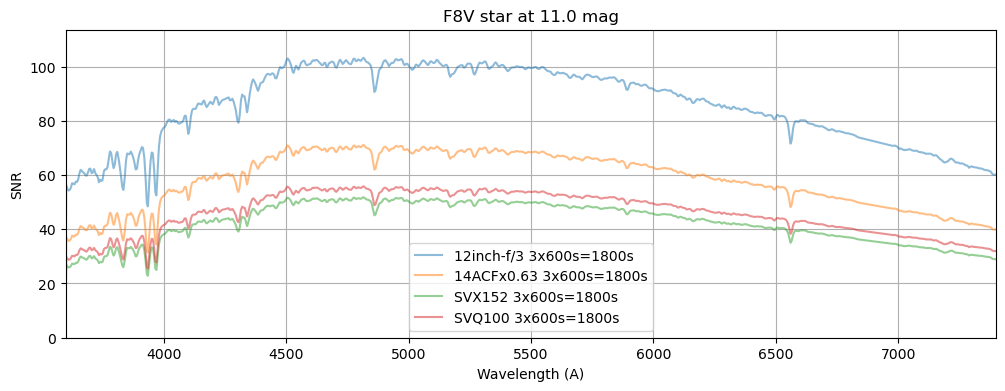

In [5]:
Alpy600.generate_binset(IMX183)
plt.figure(figsize=(12,4))
plt.title(f'{sptype} star at {mag:.1f} mag')
peakSNR = 0
for t,tel in enumerate(telescopes):
    SNR = spectra[tel.name]/variance[tel.name]**0.5
    label = f"{tel.name} {nexp[t]:d}x{exptimes[t]:.0f}s={nexp[t]*exptimes[t]:.0f}s"
    plt.plot(Alpy600.binset, SNR, alpha=0.5, label=label)
    peakSNR = peakSNR if max(SNR) <= peakSNR else max(SNR)
plt.ylabel('SNR')
plt.xlabel('Wavelength (A)')
plt.xlim(min(Alpy600.binset), max(Alpy600.binset))
plt.ylim(0,1.1*peakSNR)
plt.grid()
plt.legend(loc='best')
plt.show()

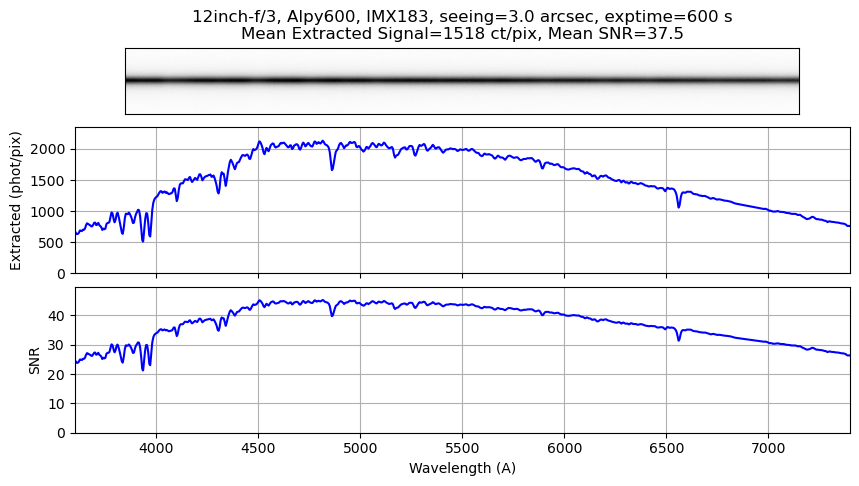

In [6]:
# 10*FWHM: 848, 27.1
# 5*FWHM: 1518, 37.5
spec, var, im = SpecETC(star, exptime=600*u.second, seeing=3.0*u.arcsec,
                        telescope=Newtonian12, spectrograph=Alpy600, detector=IMX183)

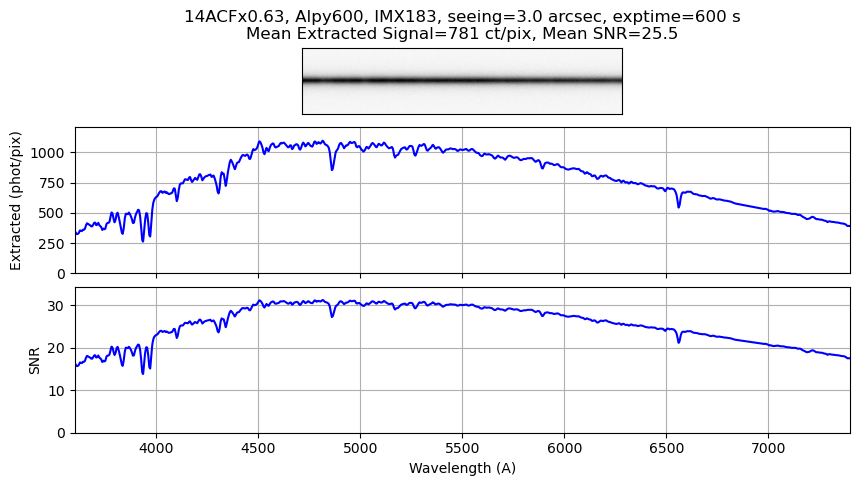

In [7]:
# 10*FWHM: 508, 19.7
spec, var, im = SpecETC(star, exptime=600*u.second, seeing=3.0*u.arcsec,
                        telescope=ACF14reduced, spectrograph=Alpy600, detector=IMX183)

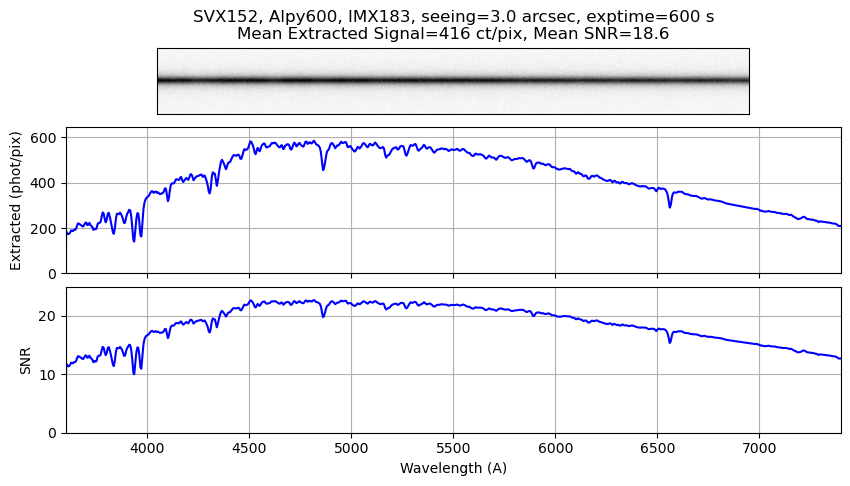

In [8]:
# 10*FWHM: 326, 15.9
spec, var, im = SpecETC(star, exptime=600*u.second, seeing=3.0*u.arcsec,
                        telescope=SVX152, spectrograph=Alpy600, detector=IMX183)

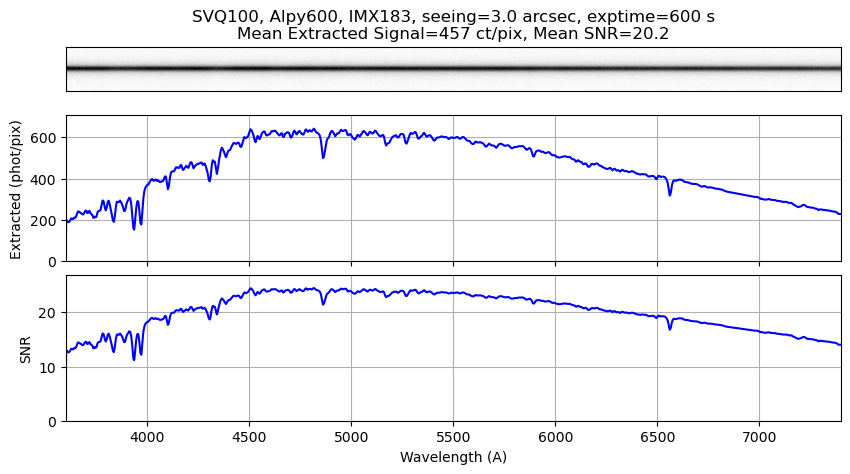

In [9]:
# 10*FWHM: 354, 17.2
spec, var, im = SpecETC(star, exptime=600*u.second, seeing=3.0*u.arcsec,
                        telescope=SVQ100, spectrograph=Alpy600, detector=IMX183)

# Check Sky Brightness Matches Expectation

In [10]:
import synphot
from astropy import units as u
import numpy as np

In [11]:
# Verify Sky Brightness
sky = get_sky_spectrum(mag=19)
Vfilter = synphot.SpectralElement.from_filter('johnson_V')
skyobs = synphot.Observation(sky, Vfilter)
print(skyobs.countrate(1*u.cm**2))

vega = synphot.SourceSpectrum.from_vega()
vegaobs = synphot.Observation(vega, Vfilter)
print(vegaobs.countrate(1*u.cm**2))

msky = -2.5*np.log10(skyobs.countrate(1*u.cm**2)/vegaobs.countrate(1*u.cm**2))
msky

0.021413788954463803 ct / s
857771.2198307253 ct / s


<Quantity 19.00669488>